<h3>Régression linéaire simple avec scikit-learn<h3>

In [80]:
#Importation des bibliothèques
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

In [81]:
# 1) Données : surface (m²) et prix (DH)
# reshape(-1,1) : transforme en matrice colonne (obligatoire pour sklearn)
X = np.array([30,40,50,60,70,80,90,100,110,120]).reshape(-1,1)
y = np.array([125000,160000,185000,210000,248000,275000,
              310000,340000,365000,400000])

In [82]:
# 2) Division en apprentissage / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)


In [83]:
# 3) Entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
# 4) Paramètres appris
print(f"w0 (biais) = {model.intercept_:.0f}")
print(f"w1 (pente) = {model.coef_[0]:.0f}")

w0 (biais) = 30353
w1 (pente) = 3084


In [85]:
# 5) Prédictions
y_pred_test = model.predict(X_test)
y_pred_all = model.predict(X)

In [86]:
# 6) Évaluation
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)
print(f"MSE  = {mse:.0f}")
print(f"RMSE = {rmse:.0f}")
print(f"R²   = {r2:.4f}")

MSE  = 30214960
RMSE = 5497
R²   = 0.9971


In [87]:
# 7) Préparation d'une droite lisse
X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(X_line)


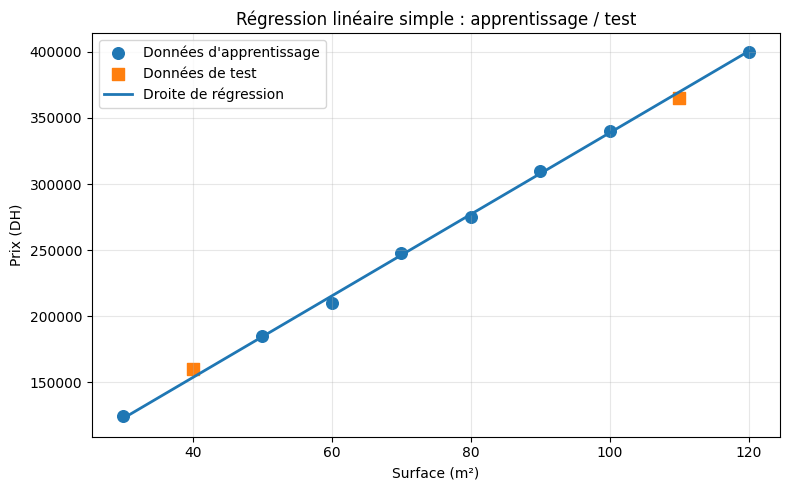

In [88]:
# 8) Visualisation améliorée
plt.figure(figsize=(8, 5))
X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(X_line)
# points d'apprentissage
plt.scatter(X_train, y_train, label="Données d'apprentissage", s=70)
# points de test
plt.scatter(X_test, y_test, label="Données de test", s=70, marker="s")
# droite de régression
plt.plot(X_line, y_line, label="Droite de régression", linewidth=2)
plt.xlabel("Surface (m²)")
plt.ylabel("Prix (DH)")
plt.title("Régression linéaire simple : apprentissage / test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Régression multiple<h3>

In [89]:

import pandas as pd # Manipulation de données sous forme de tableau
# =========================
# 1. Création des données
# =========================
# On crée un petit dataset représentant des logements
# Chaque ligne = un logement
# Chaque colonne = une caractéristique
data = {
    "surface":  [50, 60, 70, 80, 90, 100, 110, 120],      # surface en m²
    "chambres": [1, 2, 2, 3, 3, 3, 4, 4],                 # nombre de chambres
    "etage":    [1, 2, 3, 1, 4, 5, 2, 6],                 # étage
    "prix":     [180, 220, 250, 280, 310, 340, 370, 410]  # prix (en milliers DH par ex.)

}
# Conversion en DataFrame (format tableau)
df = pd.DataFrame(data)



In [90]:
# 2. Séparation des variables
# =========================
# X = variables explicatives (features)
# y = variable cible (target)
X = df[["surface", "chambres", "etage"]]  # entrées du modèle
y = df["prix"]                            # sortie à prédire

In [91]:
# 3. Création et apprentissage du modèle
# =========================
# On crée un modèle de régression linéaire
model = LinearRegression()
# Entraînement du modèle :
# Le modèle apprend les coefficients de l'équation
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
# 4. Prédictions
# =========================
# Le modèle prédit les prix à partir des données d'entrée
y_pred = model.predict(X)

In [93]:
 #5. Affichage des paramètres du modèle
# =========================
print("=== Régression linéaire multiple ===")
# w0 : constante (biais)
print(f"Intercept (w0) = {model.intercept_:.4f}")
# w1, w2, w3 : coefficients associés à chaque variable
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient de {feature} = {coef:.4f}")
# Le modèle appris est de la forme :
# prix = w0 + w1*surface + w2*chambres + w3*etage

=== Régression linéaire multiple ===
Intercept (w0) = 37.6744
Coefficient de surface = 2.5640
Coefficient de chambres = 11.2791
Coefficient de etage = 2.7907


In [95]:
# 6. Évaluation du modèle
# =========================
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

In [96]:
# Affichage des métriques
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"R²   = {r2:.4f}")

MSE  = 3.4157
RMSE = 1.8482
MAE  = 1.4244
R²   = 0.9994


In [97]:
# 7. Comparaison réel vs prédit
# =========================
# On ajoute les prédictions au tableau initial
results = df.copy()
results["prix_predit"] = y_pred
print("\nComparaison réel / prédit :")
print(results)


Comparaison réel / prédit :
   surface  chambres  etage  prix  prix_predit
0       50         1      1   180   179.941860
1       60         2      2   220   219.651163
2       70         2      3   250   248.081395
3       80         3      1   280   279.418605
4       90         3      4   310   313.430233
5      100         3      5   340   341.860465
6      110         4      2   370   370.406977
7      120         4      6   410   407.209302


<h3> Régression polynomiale<h3>

In [99]:
from sklearn.preprocessing import PolynomialFeatures # Transformation polynomiale
# =========================
# 1. Données
# =========================
# Variable explicative (entrée)
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
# Variable cible (sortie)
y = np.array([1.5, 3.8, 8.5, 15.5, 24.0, 35.5])
# Observation :
# Les valeurs de y augmentent de plus en plus vite → relation non linéaire

In [100]:
# 2. Transformation polynomiale
# =========================
# On crée des nouvelles variables : x et x²
# include_bias=False Parce que la régression linéaire ajoute déjà elle-même 
# l’intercept w0.
poly = PolynomialFeatures(degree=2, include_bias=False)  
# Transformation des données :
# Exemple : x=3 → [3, 9]
X_poly = poly.fit_transform(X)
# Maintenant le modèle travaille avec :
# X_poly = [x, x²]

In [101]:
# 3. Création et apprentissage du modèle
# =========================
# On utilise une régression linéaire classique
model = LinearRegression()
# Entraînement :
# Le modèle apprend les coefficients de :
# y = w0 + w1*x + w2*x²
model.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
# 4. Prédictions
# =========================
# Calcul des valeurs prédites pour les données existantes
y_pred = model.predict(X_poly)

In [103]:
# 5. Affichage du modèle
# =========================
print("=== Régression polynomiale ===")
# w0 : constante
print(f"Intercept (w0) = {model.intercept_:.4f}")
# w1 et w2 : coefficients
print(f"Coefficients = {model.coef_}")
# Le modèle appris est :
# y = w0 + w1*x + w2*x²

=== Régression polynomiale ===
Intercept (w0) = 1.2400
Coefficients = [-0.86142857  1.09285714]


In [104]:
# 6. Évaluation du modèle
# =========================
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"R²   = {r2:.4f}")


MSE  = 0.0215
RMSE = 0.1467
MAE  = 0.1143
R²   = 0.9998


In [105]:
# 7. Création d'une courbe lisse
# =========================
# On crée 200 points entre min(X) et max(X)
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
# On applique la même transformation polynomiale
X_new_poly = poly.transform(X_new)
# Prédictions pour tracer une courbe fluide
y_new = model.predict(X_new_poly)

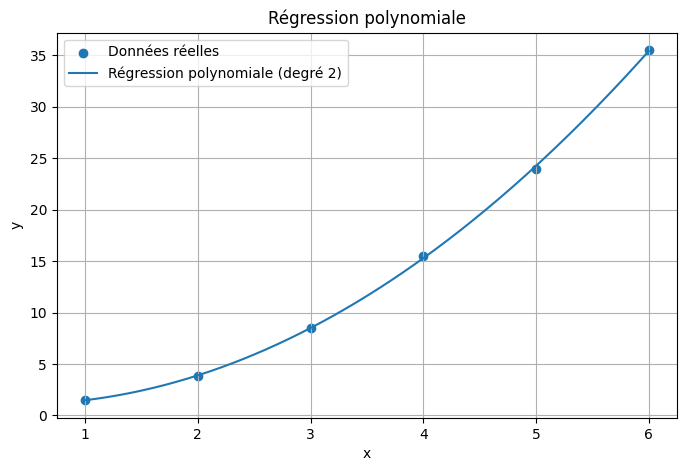

In [106]:
# 8. Visualisation
# =========================
plt.figure(figsize=(8, 5))
# Points réels
plt.scatter(X, y, label="Données réelles")
# Courbe du modèle
plt.plot(X_new, y_new, label="Régression polynomiale (degré 2)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Régression polynomiale")
plt.grid(True)
plt.legend()
plt.show()
